# Centroid Analysis — Topic Structure in Representation Space

Three analyses exploiting JBB's matched-pair structure:

1. **PCA on topic centroids** — how clustered are pairs by JBB harm category?  
2. **Per-pair harmfulness distance** — which categories / pairs are hardest to separate?  
3. **Centroid drift over turns** — does the harmful/benign gap grow as conversation deepens?  


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA

repo_root = Path('..').resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

REPR_ROOT   = repo_root / 'data' / 'representations'
FRAMEWORKS  = ['crescendo', 'actorattack', 'xteaming']
N_LAYERS    = 32
HIDDEN_DIM  = 4096
FOCAL_LAYER = 15   # 0-indexed → layer 16
TRAIN_MAX_ATTEMPT = 16

FW_COLORS = {'crescendo': '#d62728', 'actorattack': '#ff7f0e', 'xteaming': '#2ca02c'}


In [2]:
# Load trajectory data (same as nb05)
def assign_category(row):
    if row['goal_type'] == 'harmful':
        return 'accepted_harmful' if row['attack_success'] else 'refused_harmful'
    else:
        return 'accepted_harmless' if row['attack_success'] else 'refused_harmless'

traj = {}
for fw in FRAMEWORKS:
    for split in ['harmful', 'benign']:
        folder = REPR_ROOT / 'trajectories' / f'{fw}_{split}'
        meta   = pd.read_parquet(folder / 'metadata.parquet')
        h_inst = np.load(folder / 'h_inst.npy')
        h_post = np.load(folder / 'h_post_inst.npy')
        meta['category']   = meta.apply(assign_category, axis=1)
        meta['data_split'] = np.where(meta['attempt'] <= TRAIN_MAX_ATTEMPT, 'train', 'test')
        traj[(fw, split)]  = {'meta': meta, 'h_inst': h_inst, 'h_post': h_post}

# JBB category mapping: pair_id → harm category
st_meta     = pd.read_parquet(REPR_ROOT / 'single_turn' / 'harmful' / 'metadata.parquet')
pair_to_cat = dict(zip(st_meta['pair_id'], st_meta['category']))
JBB_CATS    = sorted(set(pair_to_cat.values()))
print(f'JBB categories ({len(JBB_CATS)}): {JBB_CATS}')


JBB categories (10): ['Disinformation', 'Economic harm', 'Expert advice', 'Fraud/Deception', 'Government decision-making', 'Harassment/Discrimination', 'Malware/Hacking', 'Physical harm', 'Privacy', 'Sexual/Adult content']


In [3]:
# Compute per-pair topic centroids for each framework × h_key
# t_p = (mu_harmful_p + mu_benign_p) / 2   (train split, final turn per conversation)

def compute_centroids(framework, h_key='h_inst'):
    meta_h = traj[(framework, 'harmful')]['meta']
    h_h    = traj[(framework, 'harmful')][h_key]
    meta_b = traj[(framework, 'benign')]['meta']
    h_b    = traj[(framework, 'benign')][h_key]

    pids_h = set(meta_h[meta_h['data_split'] == 'train']['pair_id'].unique())
    pids_b = set(meta_b[meta_b['data_split'] == 'train']['pair_id'].unique())
    pids   = sorted(pids_h & pids_b)

    records = []
    for pid in pids:
        mask_h = (meta_h['data_split'] == 'train') & (meta_h['pair_id'] == pid)
        sub_h  = meta_h[mask_h]
        if len(sub_h) == 0: continue
        idx_h = sub_h.groupby('conversation_id')['turn_k'].idxmax()
        pos_h = meta_h.index.get_indexer(idx_h.values)
        mu_h  = h_h[pos_h].astype(np.float32).mean(axis=0)   # (32, 4096)

        mask_b = (meta_b['data_split'] == 'train') & (meta_b['pair_id'] == pid)
        sub_b  = meta_b[mask_b]
        if len(sub_b) == 0: continue
        idx_b = sub_b.groupby('conversation_id')['turn_k'].idxmax()
        pos_b = meta_b.index.get_indexer(idx_b.values)
        mu_b  = h_b[pos_b].astype(np.float32).mean(axis=0)   # (32, 4096)

        records.append({
            'pair_id':   pid,
            'jbb_cat':   pair_to_cat.get(pid, 'unknown'),
            'mu_h':      mu_h,   # (32, 4096)
            'mu_b':      mu_b,
            'centroid':  (mu_h + mu_b) / 2.0,
            'diff':      mu_h - mu_b,
        })
    return records

centroids = {}
for fw in FRAMEWORKS:
    for h_key in ['h_inst', 'h_post']:
        centroids[(fw, h_key)] = compute_centroids(fw, h_key)
        print(f'{fw} / {h_key}: {len(centroids[(fw, h_key)])} pairs')


crescendo / h_inst: 100 pairs
crescendo / h_post: 100 pairs
actorattack / h_inst: 100 pairs
actorattack / h_post: 100 pairs
xteaming / h_inst: 100 pairs
xteaming / h_post: 100 pairs


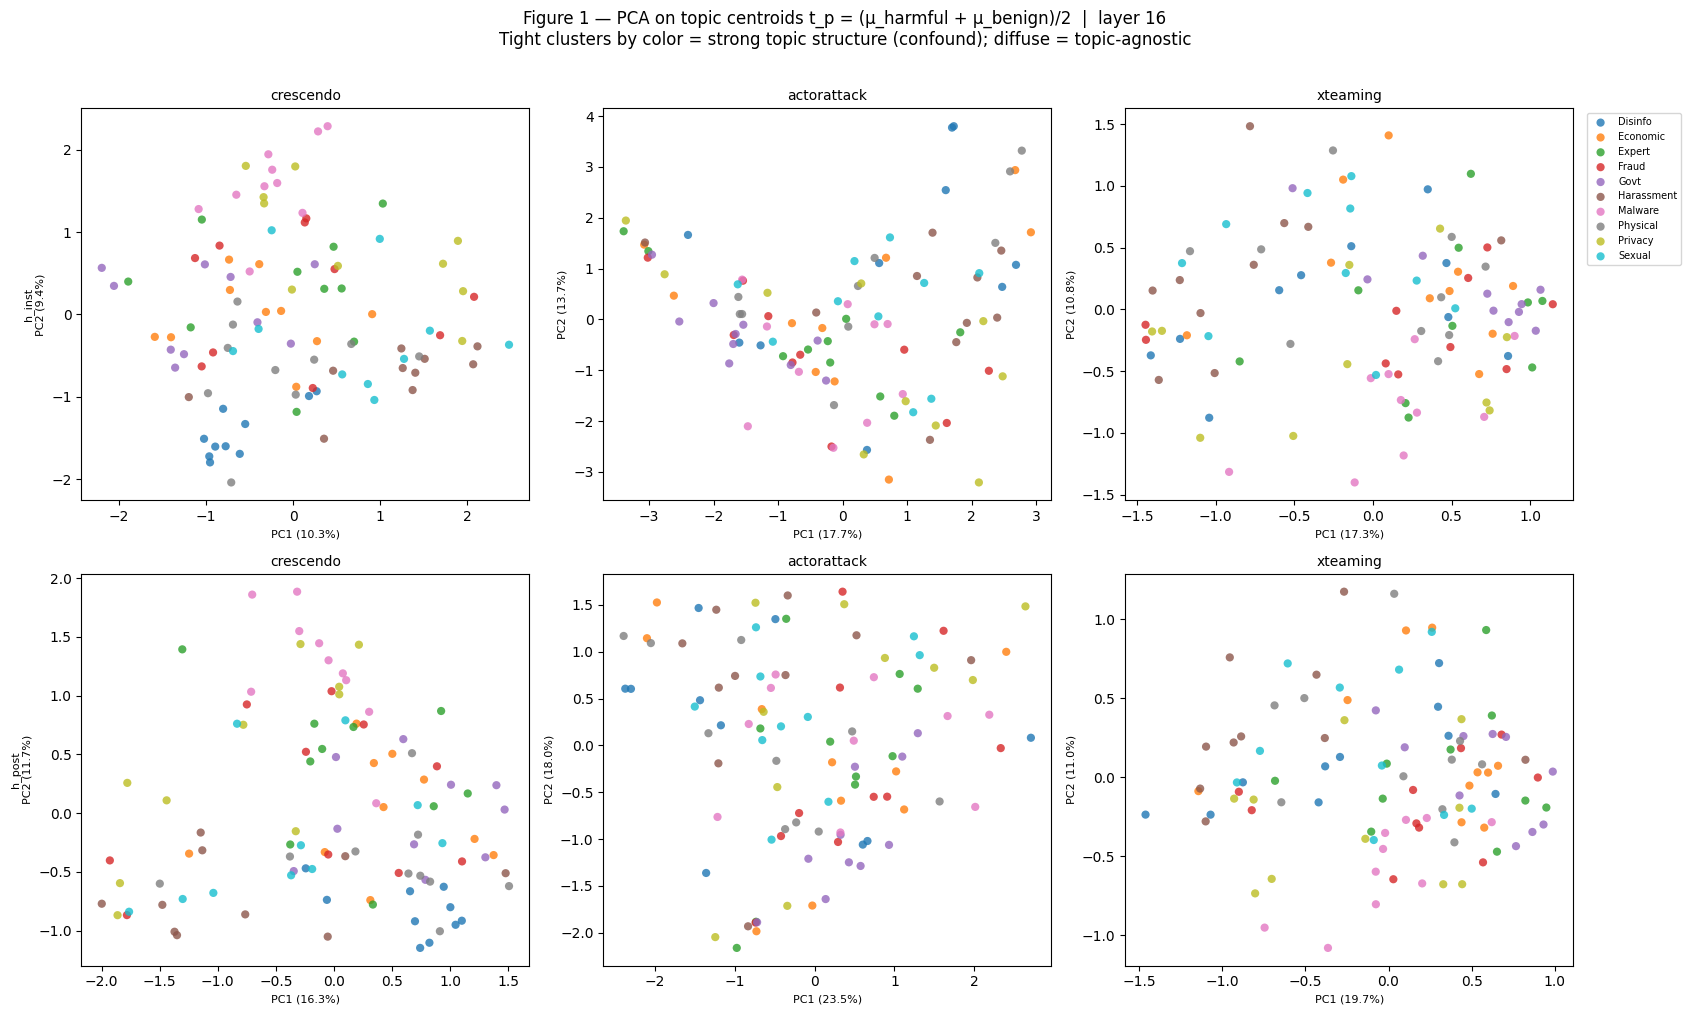

Saved figures/06_fig1_centroid_pca.png


In [4]:
# Figure 1 — PCA on topic centroids per framework
# Each point = one pair_id; colored by JBB harm category
# If crescendo is topic-indirect, its centroids should cluster less tightly by category

CAT_COLORS = {
    cat: cm.tab10(i / len(JBB_CATS))
    for i, cat in enumerate(JBB_CATS)
}
SHORT = {
    'Disinformation':             'Disinfo',
    'Economic harm':              'Economic',
    'Expert advice':              'Expert',
    'Fraud/Deception':            'Fraud',
    'Government decision-making': 'Govt',
    'Harassment/Discrimination':  'Harassment',
    'Malware/Hacking':            'Malware',
    'Physical harm':              'Physical',
    'Privacy':                    'Privacy',
    'Sexual/Adult content':       'Sexual',
}

fig, axes = plt.subplots(2, 3, figsize=(17, 10))

for row, h_key in enumerate(['h_inst', 'h_post']):
    for col, fw in enumerate(FRAMEWORKS):
        ax   = axes[row, col]
        recs = centroids[(fw, h_key)]

        # Stack centroid vectors at focal layer: (n_pairs, 4096)
        C    = np.array([r['centroid'][FOCAL_LAYER] for r in recs], dtype=np.float32)
        cats = [r['jbb_cat'] for r in recs]

        pca  = PCA(n_components=2)
        C2   = pca.fit_transform(C)   # (n_pairs, 2)

        for cat in JBB_CATS:
            mask = [c == cat for c in cats]
            ax.scatter(C2[mask, 0], C2[mask, 1],
                       c=[CAT_COLORS[cat]], label=SHORT.get(cat, cat),
                       s=35, alpha=0.8, edgecolors='none')

        var  = pca.explained_variance_ratio_
        ax.set_xlabel(f'PC1 ({var[0]*100:.1f}%)', fontsize=8)
        ax.set_ylabel(f'PC2 ({var[1]*100:.1f}%)', fontsize=8)
        ax.set_title(f'{fw}', fontsize=10)
        if col == 0:
            pos_label = 'h_inst' if h_key == 'h_inst' else 'h_post'
            ax.set_ylabel(f'{pos_label}\nPC2 ({var[1]*100:.1f}%)', fontsize=8)
        if row == 0 and col == 2:
            ax.legend(fontsize=7, bbox_to_anchor=(1.02, 1), loc='upper left')

plt.suptitle(
    f'Figure 1 — PCA on topic centroids t_p = (μ_harmful + μ_benign)/2  |  layer {FOCAL_LAYER+1}\n'
    'Tight clusters by color = strong topic structure (confound); diffuse = topic-agnostic',
    y=1.01,
)
plt.tight_layout()
plt.savefig('../figures/06_fig1_centroid_pca.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/06_fig1_centroid_pca.png')


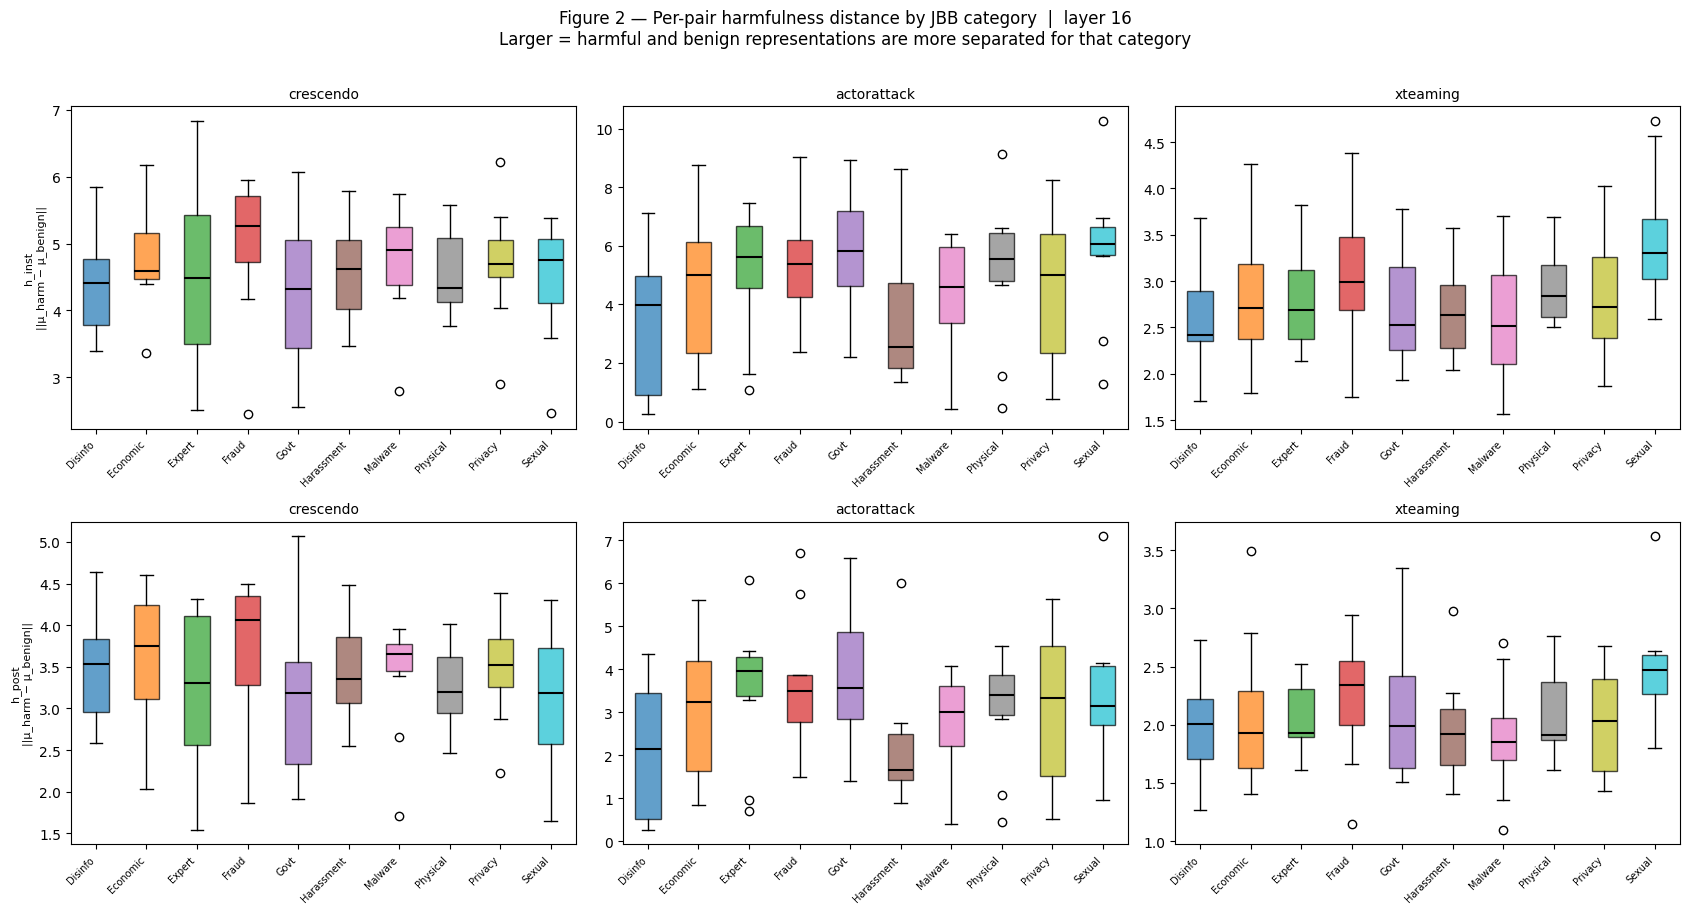

Saved figures/06_fig2_pair_distance.png


In [5]:
# Figure 2 — Per-pair harmfulness distance per JBB category
# dist_p = ||mu_harmful_p - mu_benign_p|| at focal layer
# Larger distance = easier to separate harmful from benign for that pair/topic

fig, axes = plt.subplots(2, 3, figsize=(17, 9))

for row, h_key in enumerate(['h_inst', 'h_post']):
    for col, fw in enumerate(FRAMEWORKS):
        ax   = axes[row, col]
        recs = centroids[(fw, h_key)]

        dists = np.array([np.linalg.norm(r['diff'][FOCAL_LAYER]) for r in recs])
        cats  = [r['jbb_cat'] for r in recs]

        # Box plot per category
        data_by_cat = []
        labels_cat  = []
        for cat in JBB_CATS:
            vals = dists[[c == cat for c in cats]]
            if len(vals) > 0:
                data_by_cat.append(vals)
                labels_cat.append(SHORT.get(cat, cat))

        bp = ax.boxplot(data_by_cat, patch_artist=True, medianprops={'color': 'black', 'lw': 1.5})
        for patch, cat in zip(bp['boxes'], labels_cat):
            full_cat = next((k for k, v in SHORT.items() if v == cat), cat)
            patch.set_facecolor(CAT_COLORS.get(full_cat, 'gray'))
            patch.set_alpha(0.7)

        ax.set_xticks(range(1, len(labels_cat)+1))
        ax.set_xticklabels(labels_cat, rotation=45, ha='right', fontsize=7)
        ax.set_title(fw, fontsize=10)
        if col == 0:
            pos_label = 'h_inst' if h_key == 'h_inst' else 'h_post'
            ax.set_ylabel(f'{pos_label}\n||μ_harm − μ_benign||', fontsize=8)

plt.suptitle(
    f'Figure 2 — Per-pair harmfulness distance by JBB category  |  layer {FOCAL_LAYER+1}\n'
    'Larger = harmful and benign representations are more separated for that category',
    y=1.01,
)
plt.tight_layout()
plt.savefig('../figures/06_fig2_pair_distance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/06_fig2_pair_distance.png')


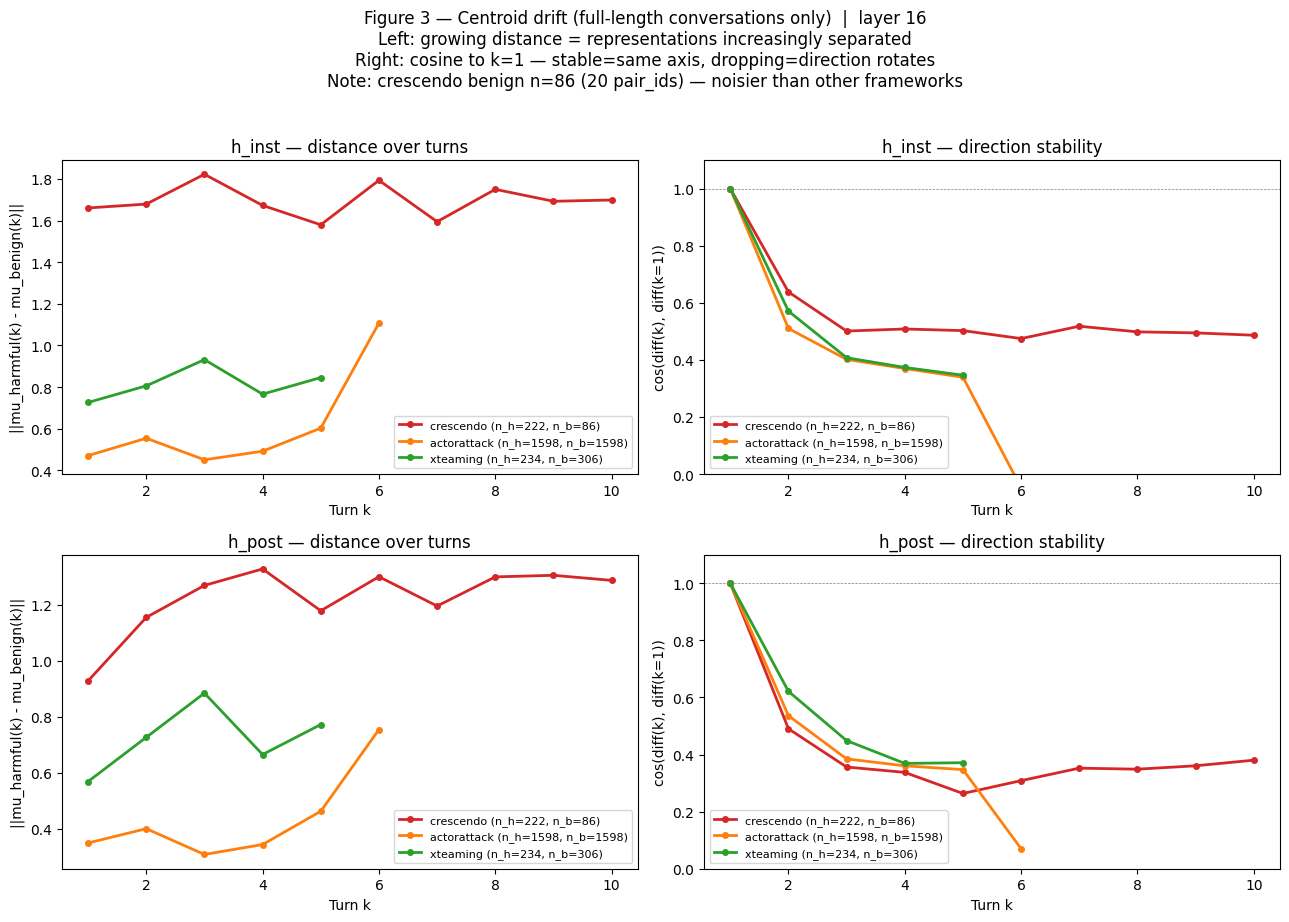

Saved figures/06_fig3_centroid_drift.png
crescendo: n_h=222, n_b=86, full_k=10
actorattack: n_h=1598, n_b=1598, full_k=6
xteaming: n_h=234, n_b=306, full_k=5


In [8]:
# Figure 3 — Centroid drift over turns (full-length conversations only)
#
# Restricting to conversations that run the full length of their framework
# ensures the sample composition is constant across all turns k — so any
# direction rotation is not an artefact of shorter conversations dropping out.
#
# Full lengths: crescendo=10, actorattack=6, xteaming=5
# Caveat: crescendo benign only covers 20 pair_ids at full length.

FULL_K = {'crescendo': 10, 'actorattack': 6, 'xteaming': 5}


def compute_centroid_drift(framework, h_key='h_inst', layer=FOCAL_LAYER):
    meta_h = traj[(framework, 'harmful')]['meta']
    h_h    = traj[(framework, 'harmful')][h_key]
    meta_b = traj[(framework, 'benign')]['meta']
    h_b    = traj[(framework, 'benign')][h_key]

    full_k  = FULL_K[framework]

    train_h = meta_h[meta_h['data_split'] == 'train']
    train_b = meta_b[meta_b['data_split'] == 'train']

    full_convs_h = (train_h.groupby('conversation_id')['turn_k']
                    .max().loc[lambda s: s >= full_k].index)
    full_convs_b = (train_b.groupby('conversation_id')['turn_k']
                    .max().loc[lambda s: s >= full_k].index)

    train_h = train_h[train_h['conversation_id'].isin(full_convs_h)]
    train_b = train_b[train_b['conversation_id'].isin(full_convs_b)]

    results = []
    diff_k1 = None

    for k in range(1, full_k + 1):
        rows_h = train_h[train_h['turn_k'] == k]
        rows_b = train_b[train_b['turn_k'] == k]

        pos_h = meta_h.index.get_indexer(rows_h.index)
        pos_b = meta_b.index.get_indexer(rows_b.index)

        mu_h = h_h[pos_h].astype(np.float32)[:, layer, :].mean(axis=0)
        mu_b = h_b[pos_b].astype(np.float32)[:, layer, :].mean(axis=0)

        diff = mu_h - mu_b
        dist = float(np.linalg.norm(diff))

        if diff_k1 is None:
            diff_k1   = diff / (np.linalg.norm(diff) + 1e-12)
            cos_to_k1 = 1.0
        else:
            d_norm    = diff / (np.linalg.norm(diff) + 1e-12)
            cos_to_k1 = float(np.dot(d_norm, diff_k1))

        results.append({'k': k, 'dist': dist, 'cos_to_k1': cos_to_k1,
                        'n_h': len(rows_h), 'n_b': len(rows_b)})

    return results


fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for row, h_key in enumerate(['h_inst', 'h_post']):
    for col, metric in enumerate(['dist', 'cos_to_k1']):
        ax = axes[row, col]
        for fw in FRAMEWORKS:
            res  = compute_centroid_drift(fw, h_key)
            ks   = [r['k'] for r in res]
            vals = [r[metric] for r in res]
            nh   = res[0]['n_h']
            nb_  = res[0]['n_b']
            ax.plot(ks, vals, color=FW_COLORS[fw], lw=2, marker='o', ms=4,
                    label=f'{fw} (n_h={nh}, n_b={nb_})')

        ax.set_xlabel('Turn k')
        if metric == 'dist':
            ax.set_ylabel('||mu_harmful(k) - mu_benign(k)||')
            title_str = h_key + ' — distance over turns'
        else:
            ax.axhline(1.0, color='gray', lw=0.5, ls='--')
            ax.set_ylim(0, 1.1)
            ax.set_ylabel('cos(diff(k), diff(k=1))')
            title_str = h_key + ' — direction stability'
        ax.set_title(title_str)
        ax.legend(fontsize=8)

sup = (
    'Figure 3 — Centroid drift (full-length conversations only)  |  '
    'layer ' + str(FOCAL_LAYER + 1) + '\n'
    'Left: growing distance = representations increasingly separated\n'
    'Right: cosine to k=1 — stable=same axis, dropping=direction rotates\n'
    'Note: crescendo benign n=86 (20 pair_ids) — noisier than other frameworks'
)
plt.suptitle(sup, y=1.02)
plt.tight_layout()
plt.savefig('../figures/06_fig3_centroid_drift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved figures/06_fig3_centroid_drift.png')
for fw in FRAMEWORKS:
    res = compute_centroid_drift(fw)
    nh  = res[0]['n_h']
    nb_ = res[0]['n_b']
    fk  = FULL_K[fw]
    print(f'{fw}: n_h={nh}, n_b={nb_}, full_k={fk}')
